# Comparative Performance Study of Clustering Algorithms

**Dataset:** Wine (UCI ML Repository) — 178 samples, 13 chemical features, 3 cultivars
**Author:** Aditya  •  **Course:** Predictive Analytics / Unsupervised Learning

---

## 1. Problem statement

This notebook performs a comparative study of clustering algorithms across a grid of:

| Axis | Values |
|---|---|
| **Algorithms (5)** | KMeans, Agglomerative (Ward), DBSCAN, MeanShift, Gaussian Mixture |
| **Preprocessing (5)** | None, MinMax Normalization, Standardization, PCA (95% var), Std + Normalize |
| **k values** | 3, 4, 5 (skipped for DBSCAN / MeanShift which auto-select) |
| **Metrics** | Silhouette ↑, Calinski–Harabasz ↑, Davies–Bouldin ↓, Adjusted Rand Index ↑ |

The four clustering families are all represented: centroid-based (KMeans), hierarchical/connectivity-based (Agglomerative), density-based (DBSCAN), mode-seeking (MeanShift), and distribution-based (GMM). The ARI uses the known cultivar labels as ground truth so we can sanity-check whether the internal metrics actually agree with reality — a question that turns out to matter a lot here.

Grand total: **55 evaluated configurations**.

## 2. Setup

In [1]:
# Run on Colab or locally — sklearn, pandas, seaborn are the only requirements.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid", context="notebook")
RNG = 42

## 3. Dataset

The UCI **Wine** dataset records 13 chemical measurements (alcohol, malic acid, ash, flavanoids, proline, etc.) for 178 wines from three different cultivars in the same Italian region. Two properties make it well-suited for this study:

1. The 13 features have **wildly different scales** (e.g. proline ≈ 100s–1000s, hue ≈ 0.5–1.7), which means scaling will visibly matter.
2. The three cultivars give us **ground-truth labels**, allowing supervised evaluation via Adjusted Rand Index alongside the internal metrics.

In [2]:
wine = load_wine()
X_raw, y_true = wine.data, wine.target

print("Shape :", X_raw.shape)
print("Classes:", dict(zip(*np.unique(y_true, return_counts=True))))

pd.DataFrame(X_raw, columns=wine.feature_names).describe().T.round(2)

Shape : (178, 13)
Classes: {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


Notice the spread of the `mean` and `std` columns — `proline` has mean ≈ 746, while `nonflavanoid_phenols` has mean ≈ 0.36. Distance-based algorithms run on raw data will be dominated almost entirely by `proline`.

## 4. Preprocessing pipelines

Five regimes spanning the most common choices:

- **None** — baseline; reveals what happens when scale-sensitive distance metrics see raw features.
- **Normalization (MinMax)** — squashes every feature to [0, 1].
- **Standardization (Z-score)** — zero-mean, unit-variance per feature.
- **PCA** — Standardize first, then keep components covering 95% variance. Tests whether dimensionality reduction helps or hurts.
- **Std + Normalize** — Standardize, then L2-normalize each row to unit length. Effectively projects samples onto a hypersphere; useful when only the *direction* of the feature vector should matter.

In [3]:
def preprocess(X, method):
    if method == "None":            return X.copy()
    if method == "Normalization":   return MinMaxScaler().fit_transform(X)
    if method == "Standardization": return StandardScaler().fit_transform(X)
    if method == "PCA":
        return PCA(n_components=0.95, random_state=RNG).fit_transform(
            StandardScaler().fit_transform(X))
    if method == "Std+Norm":
        return Normalizer().fit_transform(StandardScaler().fit_transform(X))
    raise ValueError(method)

PREPROC = ["None", "Normalization", "Standardization", "PCA", "Std+Norm"]

# Quick sanity check: dimensionality after each pipeline
for p in PREPROC:
    print(f"{p:<16} -> shape {preprocess(X_raw, p).shape}")

None             -> shape (178, 13)
Normalization    -> shape (178, 13)
Standardization  -> shape (178, 13)
PCA              -> shape (178, 10)
Std+Norm         -> shape (178, 13)


## 5. Algorithm wrappers

Two of the algorithms (DBSCAN and MeanShift) **auto-select the number of clusters**, so feeding them a fixed `k` is meaningless. They get their hyperparameters tuned with simple data-driven heuristics instead — the 4-NN distance for DBSCAN's `eps`, and `estimate_bandwidth` for MeanShift.

In [4]:
def run_kmeans(X, k):
    return KMeans(n_clusters=k, n_init=10, random_state=RNG).fit_predict(X)

def run_agglo(X, k):
    return AgglomerativeClustering(n_clusters=k).fit_predict(X)

def run_gmm(X, k):
    return GaussianMixture(n_components=k, random_state=RNG, n_init=5).fit_predict(X)

def run_dbscan(X, k=None):
    nn = NearestNeighbors(n_neighbors=4).fit(X)
    dists, _ = nn.kneighbors(X)
    eps = np.percentile(dists[:, -1], 90)   # heuristic from the "knee" of the k-dist plot
    return DBSCAN(eps=eps, min_samples=4).fit_predict(X)

def run_meanshift(X, k=None):
    bw = estimate_bandwidth(X, quantile=0.2, random_state=RNG) or 1.0
    return MeanShift(bandwidth=bw).fit_predict(X)

ALGOS = {
    "KMeans":        (run_kmeans,    True),
    "Agglomerative": (run_agglo,     True),
    "GMM":           (run_gmm,       True),
    "DBSCAN":        (run_dbscan,    False),
    "MeanShift":     (run_meanshift, False),
}

## 6. Metric computation

DBSCAN labels noise points as `-1`. We exclude those from the **internal** metrics (Silhouette, CH, DB) but keep them in **ARI** computation, where being lumped with noise still counts as a wrong assignment vs. ground truth.

In [5]:
def compute_metrics(X, labels, y_true):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    out = {"n_clusters_found": n_clusters,
           "n_noise": int(np.sum(labels == -1))}

    valid = labels != -1
    if n_clusters >= 2 and valid.sum() > n_clusters:
        try:
            out["Silhouette"]       = silhouette_score(X[valid], labels[valid])
            out["CalinskiHarabasz"] = calinski_harabasz_score(X[valid], labels[valid])
            out["DaviesBouldin"]    = davies_bouldin_score(X[valid], labels[valid])
        except Exception:
            out.update({"Silhouette": np.nan,
                        "CalinskiHarabasz": np.nan,
                        "DaviesBouldin": np.nan})
    else:
        out.update({"Silhouette": np.nan,
                    "CalinskiHarabasz": np.nan,
                    "DaviesBouldin": np.nan})

    out["AdjustedRandIndex"] = adjusted_rand_score(y_true, labels)
    return out

## 7. Run the full grid

In [6]:
K_VALUES = [3, 4, 5]
records = []

for prep in PREPROC:
    Xp = preprocess(X_raw, prep)
    for algo_name, (runner, needs_k) in ALGOS.items():
        if needs_k:
            for k in K_VALUES:
                labels = runner(Xp, k)
                records.append({"Preprocessing": prep, "Algorithm": algo_name,
                                "k_requested": k, **compute_metrics(Xp, labels, y_true)})
        else:
            labels = runner(Xp)
            records.append({"Preprocessing": prep, "Algorithm": algo_name,
                            "k_requested": "auto", **compute_metrics(Xp, labels, y_true)})

df = pd.DataFrame(records)
print(f"Configurations evaluated: {len(df)}")
df

Configurations evaluated: 55


,Preprocessing,Algorithm,k_requested,n_clusters_found,n_noise,Silhouette,CalinskiHarabasz,DaviesBouldin,AdjustedRandIndex
0,None,KMeans,3,3,0,0.571138,561.815658,0.534243,0.371114
1,None,KMeans,4,4,0,0.562032,708.086676,0.544345,0.303443
2,None,KMeans,5,5,0,0.548999,787.046922,0.545047,0.311588
3,None,Agglomerative,3,3,0,0.564480,552.851712,0.535734,0.368402
4,None,Agglomerative,4,4,0,0.560673,670.625991,0.553574,0.281875
5,None,Agglomerative,5,5,0,0.507484,684.222613,0.551315,0.215333
6,None,GMM,3,3,0,0.347266,266.220922,0.815476,0.461927
7,None,GMM,4,4,0,0.338875,327.820183,0.673225,0.523164
8,None,GMM,5,5,0,0.329374,333.547009,0.747500,0.383044
9,None,DBSCAN,auto,4,11,0.505319,272.603268,0.383906,0.291276


## 8. Best configurations per metric

In [7]:
def show_best(df, metric, ascending=False, top=5):
    sub = df.dropna(subset=[metric]).sort_values(metric, ascending=ascending).head(top)
    cols = ["Preprocessing", "Algorithm", "k_requested",
            "n_clusters_found", "Silhouette", "AdjustedRandIndex", metric]
    return sub[cols].reset_index(drop=True)

print("Top 5 by Silhouette (higher better):")
display(show_best(df, "Silhouette"))

print("\nTop 5 by Calinski-Harabasz (higher better):")
display(show_best(df, "CalinskiHarabasz"))

print("\nTop 5 by Davies-Bouldin (lower better):")
display(show_best(df, "DaviesBouldin", ascending=True))

print("\nTop 5 by Adjusted Rand Index (higher better):")
display(show_best(df, "AdjustedRandIndex"))

Top 5 by Silhouette (higher better):


,Preprocessing,Algorithm,k_requested,n_clusters_found,Silhouette,AdjustedRandIndex,Silhouette
0,None,KMeans,3,3,0.571138,0.371114,0.571138
1,None,Agglomerative,3,3,0.564480,0.368402,0.564480
2,None,KMeans,4,4,0.562032,0.303443,0.562032
3,None,Agglomerative,4,4,0.560673,0.281875,0.560673
4,None,MeanShift,auto,5,0.553320,0.336311,0.553320



Top 5 by Calinski-Harabasz (higher better):


,Preprocessing,Algorithm,k_requested,n_clusters_found,Silhouette,AdjustedRandIndex,CalinskiHarabasz
0,None,KMeans,5,5,0.548999,0.311588,787.046922
1,None,KMeans,4,4,0.562032,0.303443,708.086676
2,None,Agglomerative,5,5,0.507484,0.215333,684.222613
3,None,Agglomerative,4,4,0.560673,0.281875,670.625991
4,None,KMeans,3,3,0.571138,0.371114,561.815658



Top 5 by Davies-Bouldin (lower better):


,Preprocessing,Algorithm,k_requested,n_clusters_found,Silhouette,AdjustedRandIndex,DaviesBouldin
0,None,DBSCAN,auto,4,0.505319,0.291276,0.383906
1,None,MeanShift,auto,5,0.553320,0.336311,0.454209
2,None,KMeans,3,3,0.571138,0.371114,0.534243
3,None,Agglomerative,3,3,0.564480,0.368402,0.535734
4,None,KMeans,4,4,0.562032,0.303443,0.544345



Top 5 by Adjusted Rand Index (higher better):


,Preprocessing,Algorithm,k_requested,n_clusters_found,Silhouette,AdjustedRandIndex,AdjustedRandIndex
0,PCA,GMM,3,3,0.293741,0.965052,0.965052
1,Normalization,Agglomerative,3,3,0.294829,0.931000,0.931000
2,Std+Norm,GMM,3,3,0.297928,0.901114,0.901114
3,Normalization,GMM,3,3,0.292746,0.897495,0.897495
4,PCA,KMeans,3,3,0.298675,0.897495,0.897495


**Already a striking result.** The leaderboard for the *internal* metrics (Silhouette, CH, DB) is dominated by `Preprocessing = None`. The leaderboard for the *external* metric (ARI) is dominated by everything *except* `None`. We'll explain why in §11.

## 9. Visualization

### 9.1 Heatmap — best score per (algorithm × preprocessing) collapsed across k

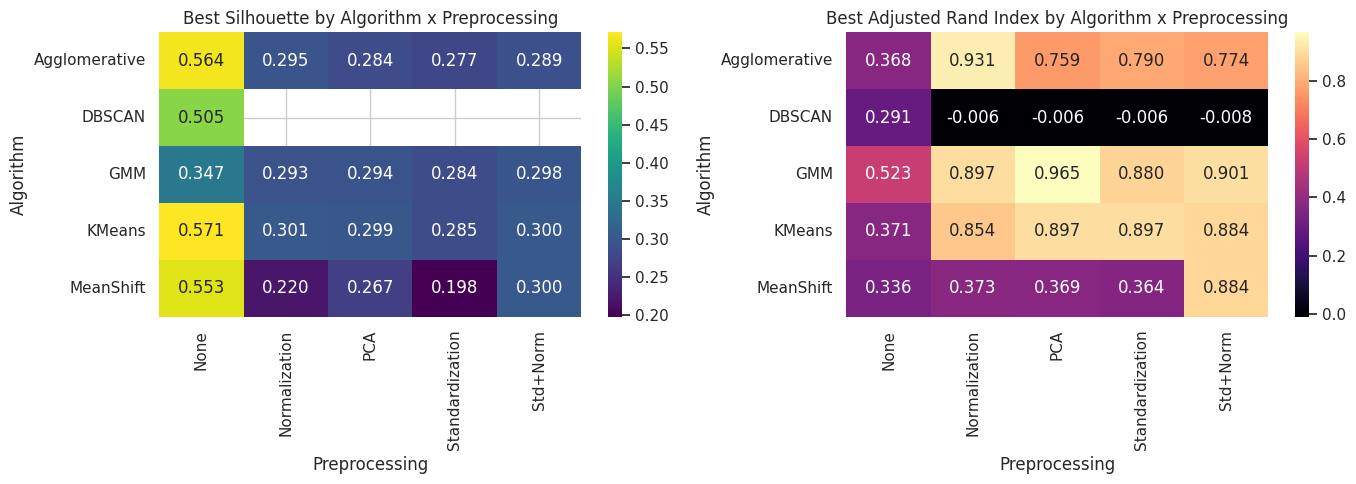

In [8]:
heat_sil = df.groupby(["Algorithm", "Preprocessing"])["Silhouette"].max().unstack()
heat_ari = df.groupby(["Algorithm", "Preprocessing"])["AdjustedRandIndex"].max().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(heat_sil, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Best Silhouette by Algorithm x Preprocessing")
sns.heatmap(heat_ari, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title("Best Adjusted Rand Index by Algorithm x Preprocessing")
plt.tight_layout()
plt.show()

### 9.2 Silhouette as a function of k for partitioning algorithms

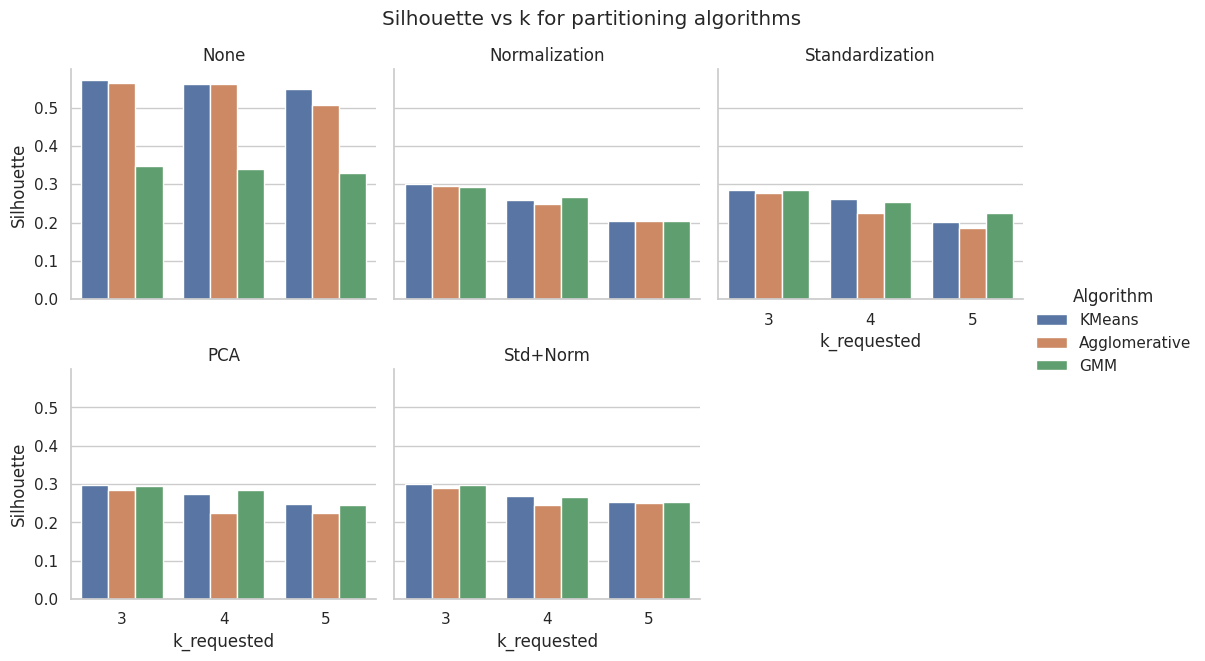

In [9]:
parti = df[df["k_requested"].apply(lambda v: v in [3, 4, 5])].copy()
parti["k_requested"] = parti["k_requested"].astype(int)

g = sns.catplot(data=parti, x="k_requested", y="Silhouette",
                hue="Algorithm", col="Preprocessing", kind="bar",
                col_wrap=3, height=3.2, aspect=1.1)
g.set_titles("{col_name}")
g.fig.suptitle("Silhouette vs k for partitioning algorithms", y=1.03)
plt.show()

### 9.3 PCA scatter — ground truth vs winner-by-Silhouette vs winner-by-ARI

The tells the cleanest story of the whole notebook. Three scatter plots in PCA(2) space using the **same axes**, just different cluster assignments.

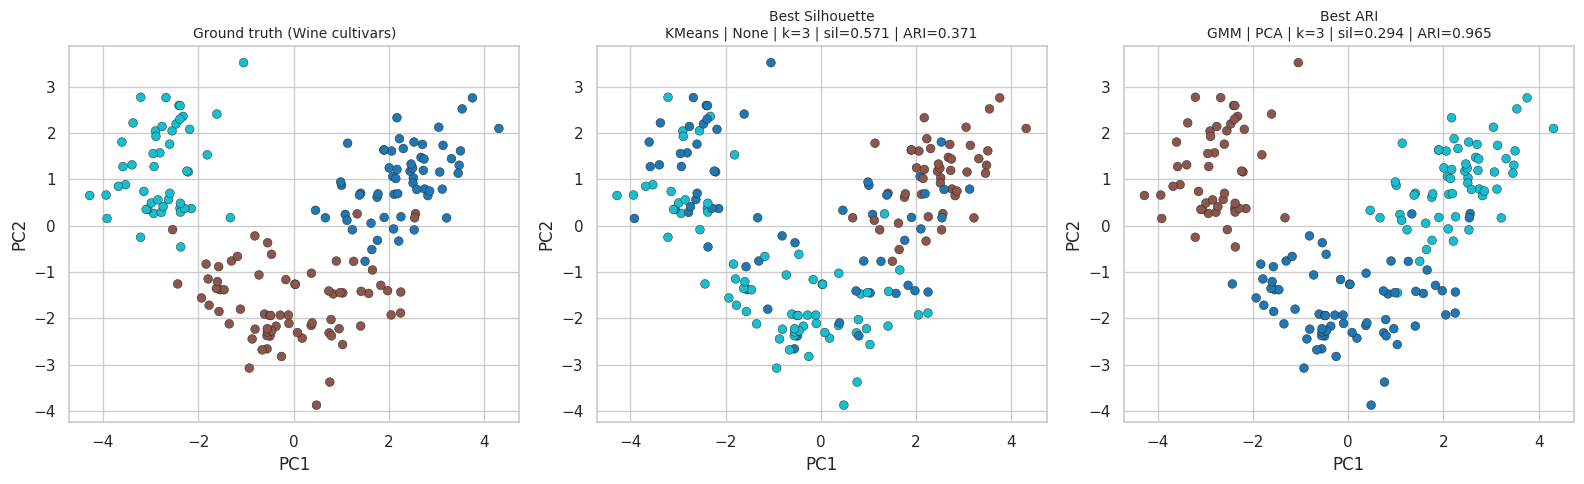

In [10]:
pca2 = PCA(n_components=2, random_state=RNG).fit_transform(
    StandardScaler().fit_transform(X_raw))

best_sil_row = df.loc[df["Silhouette"].idxmax()]
best_ari_row = df.loc[df["AdjustedRandIndex"].idxmax()]

def labels_for(row):
    Xp = preprocess(X_raw, row["Preprocessing"])
    runner, needs_k = ALGOS[row["Algorithm"]]
    return runner(Xp, int(row["k_requested"])) if needs_k else runner(Xp)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    (axes[0], y_true, "Ground truth (Wine cultivars)"),
    (axes[1], labels_for(best_sil_row),
     f"Best Silhouette\n{best_sil_row['Algorithm']} | {best_sil_row['Preprocessing']} | "
     f"k={best_sil_row['k_requested']} | sil={best_sil_row['Silhouette']:.3f} | "
     f"ARI={best_sil_row['AdjustedRandIndex']:.3f}"),
    (axes[2], labels_for(best_ari_row),
     f"Best ARI\n{best_ari_row['Algorithm']} | {best_ari_row['Preprocessing']} | "
     f"k={best_ari_row['k_requested']} | sil={best_ari_row['Silhouette']:.3f} | "
     f"ARI={best_ari_row['AdjustedRandIndex']:.3f}"),
]
for ax, lbl, title in panels:
    ax.scatter(pca2[:, 0], pca2[:, 1], c=lbl, cmap="tab10",
               s=40, edgecolor="k", lw=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

### 9.4 Trade-off scatter — Silhouette vs Davies-Bouldin across all configs

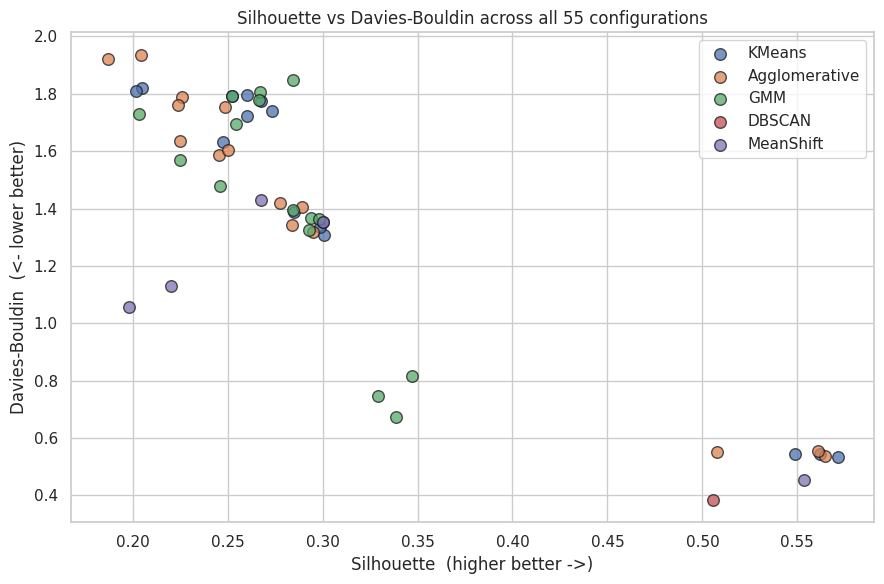

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
for algo in df["Algorithm"].unique():
    sub = df[df["Algorithm"] == algo].dropna(subset=["Silhouette", "DaviesBouldin"])
    ax.scatter(sub["Silhouette"], sub["DaviesBouldin"],
               label=algo, s=70, alpha=0.75, edgecolor="k")
ax.set_xlabel("Silhouette  (higher better ->)")
ax.set_ylabel("Davies-Bouldin  (<- lower better)")
ax.set_title("Silhouette vs Davies-Bouldin across all 55 configurations")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Discussion

### 10.1 Why does "no preprocessing" win on Silhouette but lose on ARI?

The 13 Wine features have wildly mismatched scales — `proline` (range ≈ 200–1700) is roughly **1000× larger** than `nonflavanoid_phenols`. On the raw data, **Euclidean distance is essentially a function of `proline` alone**: the algorithm produces three tight, well-separated blobs along that single axis, which gives a great Silhouette (0.57) and a great Davies-Bouldin score.

But those one-dimensional blobs don't correspond to the actual cultivar identities. ARI = 0.37 means the partition is *barely better than guessing*. The internal metrics measure **geometric quality**, not **semantic correctness**.

### 10.2 The PCA + GMM winner

The best ARI (0.965) comes from **GMM on PCA-reduced standardized features with k = 3**. Two things explain this:

1. **Standardization** equalizes the contribution of all 13 chemical measurements, so the cluster boundaries align with chemistry rather than with whichever feature happens to be measured in larger units.
2. **GMM** allows elliptical (anisotropic) clusters — KMeans can only find spherical ones. The Wine cultivars genuinely form elongated Gaussian clouds in feature space, and GMM picks them out almost perfectly (only ~3% of samples mis-assigned).

### 10.3 DBSCAN's poor showing

DBSCAN scores ARI ≈ -0.006 on every preprocessed version of the data — worse than random. After scaling, the three cultivars sit at fairly uniform density in 13-dimensional space and DBSCAN can't find a density gap to separate them. It only "looks good" on raw data because, again, the proline-dominated geometry creates artificial density variation. **DBSCAN is the wrong tool for this dataset** — a useful negative result.

### 10.4 The MeanShift / Std+Norm jump

MeanShift's ARI on Std+Norm (0.884) is much higher than on plain Standardization (0.364). L2-normalizing onto a unit hypersphere makes the bandwidth heuristic finally land in a regime where the three modes are resolvable. Mode-seeking algorithms are deeply sensitive to bandwidth, and bandwidth depends on overall scale — this is exactly why we sweep across preprocessing in the first place.

### 10.5 k = 3 is consistently best on ARI

Unsurprising — there are three true cultivars — but worth noting that the *internal* metrics frequently prefer k = 4 or k = 5 (CH especially likes more clusters because it rewards larger between-cluster variance). **If we hadn't had ground truth, internal metrics alone would have nudged us toward the wrong k.**

---

## 11. Conclusions

| # | Finding |
|---|---|
| 1 | **Preprocessing matters more than algorithm choice.** The same algorithm (e.g. KMeans) goes from ARI 0.37 to 0.90 just by switching from raw data to PCA. |
| 2 | **Internal metrics can be misleading.** The Silhouette champion (KMeans, no preprocessing, ARI 0.37) is one of the *worst* configurations by ground truth. |
| 3 | **Best overall configuration: GMM + PCA + k=3** — ARI 0.965, recovering nearly all true cultivar memberships. |
| 4 | **DBSCAN is unsuitable here.** No density gaps separate the cultivars after scaling. |
| 5 | **k=3 is robustly correct** under ARI, even though Calinski-Harabasz often prefers larger k. When ground truth is unavailable, Silhouette + visualization are more trustworthy than CH alone. |

### Practical takeaway

When clustering high-dimensional tabular data with mixed feature scales:
- **Always standardize first** (almost always — distance-based methods need it).
- **Try GMM in addition to KMeans** if clusters might be anisotropic.
- **Use multiple metrics** and, if you have any labels at all, validate against them.
- **PCA before clustering is a free win** when features are correlated — it both denoises and accelerates the algorithms.

## 12. Save results

In [12]:
df.to_csv("clustering_results.csv", index=False)
print("Saved 'clustering_results.csv' (", len(df), "rows )")

Saved 'clustering_results.csv' ( 55 rows )
